In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler

import random
from datetime import datetime
from scipy.stats import skewnorm
import ipycytoscape

from IPython.display import clear_output


MODEL_WITH_MASK = True


<Axes: >

2024-05-08 18:00:00


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 400000, 'idealEdgeLength': 100, 'gravity': …

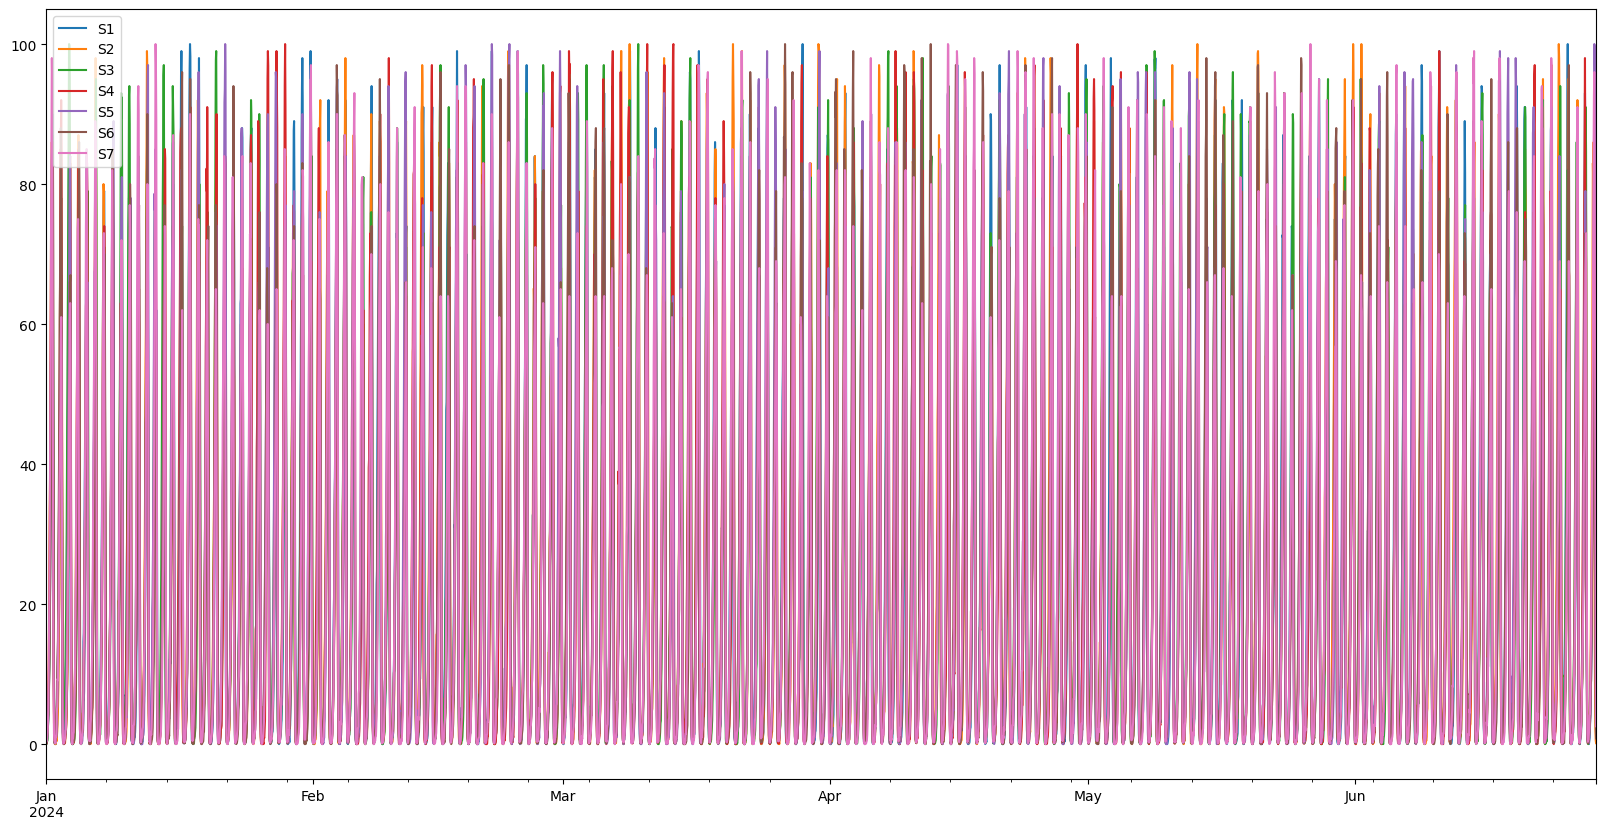

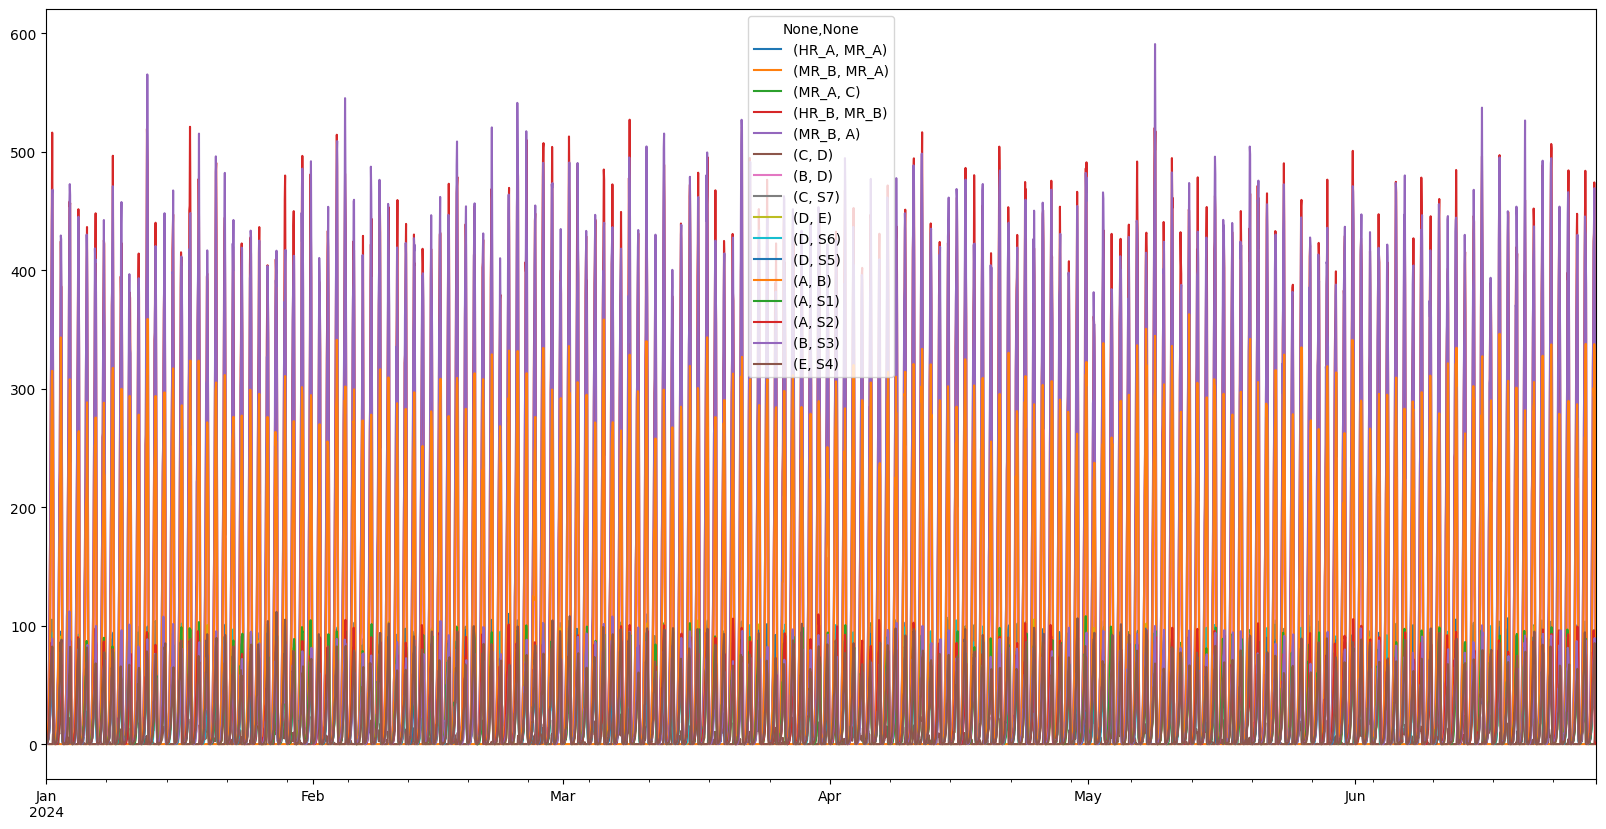

In [2]:
def create_skewed_series(n_points, max_val, skewness, sigma=1.0):
    """
    Generates a pandas Series of random numbers following a Skew Normal distribution,
    shifted so the maximum value equals 'max_val'.

    Args:
        n_points (int): The number of data points to generate.
        max_val (float): The maximum value (ceiling) of the dataset.
        skewness (float): The skew factor. 
                          0 = Normal distribution (symmetric).
                          Positive = Tail on the right (mass on left).
                          Negative = Tail on the left (mass on right).
        sigma (float): The scale (standard deviation) or 'width' of the curve.

    Returns:
        pd.Series: A Series containing the generated data.
    """
    # 1. Generate the raw Skew Normal distribution
    # 'a' is the skewness parameter
    # 'loc' is the mean, 'scale' is the standard deviation (sigma)
    raw_data = skewnorm.rvs(a=skewness, loc=0, scale=sigma, size=n_points)

    # 2. Shift the data to respect the 'max_val' constraint
    # We find the current generated max, and shift the whole dataset
    # so that the new max hits your target exactly.
    current_max = np.max(raw_data)
    shift_amount = max_val - current_max
    final_data = raw_data + shift_amount

    return pd.Series(final_data)

def create_day_demand(day:datetime, node:str, amp_range:int = (60, 100), skewness_range:int = (-6,-3), sigma_range:int = (7, 10), nn:int = 1440, points:int = 24):

    _max_val = random.randint(amp_range[0], amp_range[1])
    _skewness = random.randint(skewness_range[0], skewness_range[1])
    _sigma = random.randint(sigma_range[0], sigma_range[1])

    #print(f"Node: {node}, Max Val: {_max_val}, Skewness: {_skewness}, Sigma: {_sigma}")
    _curve = create_skewed_series(5000, _max_val, skewness=_skewness, sigma=_sigma)
    _curve = _curve.value_counts(bins=points).sort_index().reset_index(drop=True)
    _curve.name = node
    _curve.index = pd.date_range(start=day, periods=points, freq='h')
    _curve = _curve * _max_val/_curve.max()

    return _curve

def calculate_edge_flows(G, demands, capacity_attr='capacity'):
    """
    Calculates the flow through all edges in a Digraph to satisfy specific node demands.
    
    Args:
        G (nx.DiGraph): The networkx graph. Edges must have a capacity attribute.
        demands (dict): Dictionary {node_name: required_output_flow}.
        capacity_attr (str): The name of the edge attribute representing capacity.
        
    Returns:
        dict: A dictionary of dictionaries representing flow {u: {v: flow_amount}}.
    """
    # 1. Create a working copy of the graph to avoid modifying the original
    R = G.copy()
    
    # 2. Define Super Node names (ensure they don't clash with existing nodes)
    super_source = 'SUPER_SOURCE_VIRTUAL'
    super_sink = 'SUPER_SINK_VIRTUAL'
    
    # 3. Add the Super Sink
    # Connect demand nodes to Super Sink with capacity = demand
    total_demand = 0
    for node, demand in demands.items():
        if node not in R:
            raise ValueError(f"Demand node '{node}' is not in the graph.")
        R.add_edge(node, super_sink, **{capacity_attr: demand})
        total_demand += demand

    # 4. Add the Super Source
    # Identify potential sources: Nodes with 0 in-degree that aren't the super sink
    # If specific sources are known, you can pass them as a list instead of this auto-detection
    sources = [n for n in G.nodes() if G.in_degree(n) == 0]
    
    if not sources:
        # If the graph is a cycle (no 0 in-degree nodes), we might need to assume 
        # all non-demand nodes are potential sources, or raise an error.
        # Here, we default to connecting to all nodes that aren't sinks.
        sources = [n for n in G.nodes() if n not in demands]

    for source in sources:
        # Connect Super Source to sources with Infinite capacity
        R.add_edge(super_source, source, **{capacity_attr: float('inf')})

    # 5. Compute Maximum Flow
    try:
        flow_value, flow_dict = nx.maximum_flow(R, super_source, super_sink, capacity=capacity_attr)
    except nx.NetworkXError as e:
        print(f"Error computing flow: {e}")
        return {}

    # 6. Check if demands were met
    if flow_value < total_demand:
        print(f"WARNING: The network capacity ({flow_value}) is insufficient to meet total demand ({total_demand}).")
        print("Returning partial flow assignments.")

    # 7. Clean up the output
    # The flow_dict includes the virtual nodes; we need to strip them out.
    final_flow = {}
    for u, neighbors in flow_dict.items():
        # Skip if u is a virtual node
        if u in (super_source, super_sink):
            continue
            
        final_flow[u] = {}
        for v, flow in neighbors.items():
            # Skip if v is a virtual node
            if v in (super_source, super_sink):
                continue
            final_flow[u][v] = flow

    final_flow_df = pd.DataFrame(final_flow).stack().to_frame().rename(columns={0: 'Flow'}).swaplevel()

    return final_flow_df

def visualize_flow_series(data:pd.Series):
    G_vis = nx.DiGraph()
    for k,v in data.items():
        G_vis.add_edge(k[0],k[1],weight=round(v,1))
        
    cyto = ipycytoscape.CytoscapeWidget()
    cyto.graph.add_graph_from_networkx(G_vis)

    cyto.set_style([
        {
            'selector': 'node',
            'style': {
                'label': 'data(id)',
                'background-color': '#0074D9',
                'color': 'white',
                'text-valign': 'center',
                'text-halign': 'center',
                'width': '40px',
                'height': '40px',
                'font-size': '15px',
            }
        },
        {
            'selector': 'edge',
            'style': {
                'label': 'data(weight)',  
                'width': 'mapData(weight, 0, 10, 1, 8)',
                'line-color': '#9dbaea',
                'target-arrow-shape': 'triangle',
                'curve-style': 'bezier',
                'font-size': '15px',
                'color': '#555'
            }
        }
    ])

    # 4. Configure "Gravity" (Repulsion)
    # 'nodeRepulsion' controls how much they push away from each other
    cyto.set_layout(
        name='cose',
        nodeRepulsion=400000, 
        idealEdgeLength=100,
        gravity=80
    )

    cyto.layout.width = '100%'   
    cyto.layout.height = '600px'

    return cyto


G = nx.DiGraph()
G.add_edge('HR_A', 'MR_A', capacity=10000)
G.add_edge('HR_B', 'MR_B', capacity=10000)
G.add_edge('MR_B', 'MR_A', capacity=10000)
G.add_edge('MR_A', 'C', capacity=10000)

G.add_edge('C', 'D', capacity=10000)
G.add_edge('MR_B', 'A', capacity=10000)
G.add_edge('A', 'B', capacity=10000)
G.add_edge('B', 'D', capacity=10000)
G.add_edge('D', 'E', capacity=10000)

G.add_edge('C', 'S7', capacity=10000)
G.add_edge('D', 'S6', capacity=10000)
G.add_edge('D', 'S5', capacity=10000)
G.add_edge('B', 'S3', capacity=10000)
G.add_edge('A', 'S1', capacity=10000)
G.add_edge('A', 'S2', capacity=10000)
G.add_edge('E', 'S4', capacity=10000)


DEMANDS_NODES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']


DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')


DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _demands_day[_node] = create_day_demand(_day, _node)
    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)
display(DEMANDS.plot(figsize=(20,10)))


RAW_DATA = pd.DataFrame()
for k,v in DEMANDS.iterrows():
    _flow = calculate_edge_flows(G, v.to_dict() )
    _flow.columns = [k]   
    RAW_DATA = pd.concat([RAW_DATA, _flow], axis=1)

clear_output()

# SIULATING NOISE
NOISE =  np.random.normal(loc=0, scale=0.05, size=RAW_DATA.shape)
RAW_DATA = RAW_DATA*(1+NOISE)

display(RAW_DATA.T.plot(figsize=(20,10)))

timestamp = RAW_DATA.sum().idxmax() #RAW_DATA.T.sample().index[0]
print(timestamp)

visualize_flow_series(RAW_DATA.loc[:,timestamp])

### CREATION OF THE MASK


## PREPARATION OF DATA

In [3]:
SAMPLING = 'h'
TSS = RAW_DATA.T.copy()
TSS = TSS.resample(SAMPLING).mean()
TSS



HR_A MR_B       MR_A        HR_B        MR_B  \
                          MR_A MR_A          C        MR_B           A   
2024-01-01 00:00:00   0.675834  0.0   0.677611    1.653413    1.696024   
2024-01-01 01:00:00   0.539747  0.0   0.562938    1.646382    1.872328   
2024-01-01 02:00:00   0.568437  0.0   0.480601    4.153686    4.145000   
2024-01-01 03:00:00   1.699272  0.0   1.719593    6.382136    6.975254   
2024-01-01 04:00:00   2.458723  0.0   2.422120   10.708719   10.113003   
...                        ...  ...        ...         ...         ...   
2024-06-28 19:00:00  77.908845  0.0  89.041993  404.964647  397.070020   
2024-06-28 20:00:00  70.643674  0.0  76.761249  303.052472  318.965016   
2024-06-28 21:00:00  36.743148  0.0  32.767770  174.461644  152.914112   
2024-06-28 22:00:00  14.059273  0.0  15.727132   52.910049   51.894376   
2024-06-28 23:00:00   2.760693  0.0   2.971680   12.705907    9.976265   

                             C           B          C          D             \
                             D           D         S7          E         S6   
2024-01-01 00:00:00   0.483889    0.635620   0.138287   0.741915   0.257359   
2024-01-01 01:00:00   0.000000    0.556646   0.538036   0.138010   0.000000   
2024-01-01 02:00:00   0.092656    1.043765   0.511562   0.522017   0.131804   
2024-01-01 03:00:00   0.694720    2.760947   0.909693   1.728023   0.869815   
2024-01-01 04:00:00   0.950781    5.186890   1.647199   2.665137   1.558582   
...                        ...         ...        ...        ...        ...   
2024-06-28 19:00:00   4.371936  202.165462  86.036011  82.513581  46.301887   
2024-06-28 20:00:00  12.171247  193.020841  55.758383  76.499494  29.907314   
2024-06-28 21:00:00   0.716641  102.342846  32.412354  34.533381  12.105343   
2024-06-28 22:00:00   1.547459   33.078596  12.295586  15.016138   2.976865   
2024-06-28 23:00:00   0.433752    5.357189   2.416434   2.951824   0.869979   

                                         A                                B  \
                            S5           B         S1         S2         S3   
2024-01-01 00:00:00   0.195754    0.896778   0.425201   0.291458   0.273494   
2024-01-01 01:00:00   0.422174    0.540228   0.512398   0.681854   0.000000   
2024-01-01 02:00:00   0.421131    1.351831   0.407121   2.159377   0.426254   
2024-01-01 03:00:00   0.948873    3.346129   0.767409   2.211007   0.397550   
2024-01-01 04:00:00   1.921875    5.865686   2.054827   2.629975   0.557520   
...                        ...         ...        ...        ...        ...   
2024-06-28 19:00:00  88.517683  326.513935  65.947123  18.994741  89.469080   
2024-06-28 20:00:00  90.354702  282.824485  38.505391   8.524527  86.570534   
2024-06-28 21:00:00  57.773939  153.915487  14.556134   2.150571  54.732955   
2024-06-28 22:00:00  14.684374   52.620131   4.419488   0.547276  20.344458   
2024-06-28 23:00:00   2.005389   10.971204   0.428573   0.142767   5.559587   

                             E  
                            S4  
2024-01-01 00:00:00   0.619479  
2024-01-01 01:00:00   0.127418  
2024-01-01 02:00:00   0.520907  
2024-01-01 03:00:00   1.562125  
2024-01-01 04:00:00   2.639976  
...                        ...  
2024-06-28 19:00:00  85.198048  
2024-06-28 20:00:00  75.305162  
2024-06-28 21:00:00  36.068930  
2024-06-28 22:00:00  15.298220  
2024-06-28 23:00:00   2.944145  

[4320 rows x 16 columns]

### ATTENTION MASK

In [4]:
G_orig = nx.DiGraph()

for v in TSS.columns:
    G_orig.add_edge(v[0],v[1])

DEMAND_LINKS = [x for x in G_orig.edges() if x[1] in DEMANDS_NODES]

G_link = nx.line_graph(G_orig).reverse()
num_nodes = G_link.number_of_nodes()

ATT_MASK_DF = pd.DataFrame(np.ones((num_nodes, num_nodes))*float('-inf'), index=TSS.columns, columns=TSS.columns)



for line in G_link.nodes():
    ATT_MASK_DF.loc[line,line] = 0
    for neig in G_link.predecessors(line):
        ATT_MASK_DF.loc[line,neig] = 0

for line in DEMAND_LINKS:
    ATT_MASK_DF.loc[line, line] = 0

ATT_MASK_DF.loc[:,DEMAND_LINKS] = 0

display(ATT_MASK_DF)




HR_A MR_B MR_A HR_B MR_B    C    B    C    D              A       \
          MR_A MR_A    C MR_B    A    D    D   S7    E   S6   S5    B   S1   
HR_A MR_A  0.0 -inf  0.0 -inf -inf -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   
MR_B MR_A -inf  0.0  0.0 -inf -inf -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   
MR_A C    -inf -inf  0.0 -inf -inf  0.0 -inf  0.0 -inf  0.0  0.0 -inf  0.0   
HR_B MR_B -inf  0.0 -inf  0.0  0.0 -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   
MR_B A    -inf -inf -inf -inf  0.0 -inf -inf  0.0 -inf  0.0  0.0  0.0  0.0   
C    D    -inf -inf -inf -inf -inf  0.0 -inf  0.0  0.0  0.0  0.0 -inf  0.0   
B    D    -inf -inf -inf -inf -inf -inf  0.0  0.0  0.0  0.0  0.0 -inf  0.0   
C    S7   -inf -inf -inf -inf -inf -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   
D    E    -inf -inf -inf -inf -inf -inf -inf  0.0  0.0  0.0  0.0 -inf  0.0   
     S6   -inf -inf -inf -inf -inf -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   
     S5   -inf -inf -inf -inf -inf -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   
A    B    -inf -inf -inf -inf -inf -inf  0.0  0.0 -inf  0.0  0.0  0.0  0.0   
     S1   -inf -inf -inf -inf -inf -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   
     S2   -inf -inf -inf -inf -inf -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   
B    S3   -inf -inf -inf -inf -inf -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   
E    S4   -inf -inf -inf -inf -inf -inf -inf  0.0 -inf  0.0  0.0 -inf  0.0   

                  B    E  
            S2   S3   S4  
HR_A MR_A  0.0  0.0  0.0  
MR_B MR_A  0.0  0.0  0.0  
MR_A C     0.0  0.0  0.0  
HR_B MR_B  0.0  0.0  0.0  
MR_B A     0.0  0.0  0.0  
C    D     0.0  0.0  0.0  
B    D     0.0  0.0  0.0  
C    S7    0.0  0.0  0.0  
D    E     0.0  0.0  0.0  
     S6    0.0  0.0  0.0  
     S5    0.0  0.0  0.0  
A    B     0.0  0.0  0.0  
     S1    0.0  0.0  0.0  
     S2    0.0  0.0  0.0  
B    S3    0.0  0.0  0.0  
E    S4    0.0  0.0  0.0

## ITRANFORMER

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [6]:
ATT_MASK = torch.from_numpy(ATT_MASK_DF.values).float()
ATT_MASK

tensor([[0., -inf, 0., -inf, -inf, -inf, -inf, 0., -inf, 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, 0., 0., -inf, -inf, -inf, -inf, 0., -inf, 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, -inf, 0., -inf, -inf, 0., -inf, 0., -inf, 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, 0., -inf, 0., 0., -inf, -inf, 0., -inf, 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, -inf, -inf, -inf, 0., -inf, -inf, 0., -inf, 0., 0., 0., 0., 0., 0., 0.],
        [-inf, -inf, -inf, -inf, -inf, 0., -inf, 0., 0., 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, -inf, -inf, -inf, -inf, -inf, 0., 0., 0., 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., 0., 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., -inf, 0., 0., -inf, 0., 0., 0., 0.],
        [-inf, -inf,

In [7]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 50
LR = 0.001

FREQ_H = int((TSS.index[1] - TSS.index[0]).total_seconds() / 3600)


# PREDICTION FOR A DAY
SEQ_LEN = int(2*(24/FREQ_H))         # 2 days
PRED_LEN = int(1*(24/FREQ_H))          # 1 day

CHANNELS =  TSS.shape[1]
TOTAL_TIME = TSS.shape[0]
D_MODEL = 256
NUM_LAYERS = 3
NUM_HEADS = 8

print(f"FREQ_H: {FREQ_H}")
print(f"TOTAL_TIME: {TOTAL_TIME}")
print(f"SEQ_LEN: {SEQ_LEN}")
print(f"PRED_LEN: {PRED_LEN}")
print(f"CHANNELS: {CHANNELS}")
print(f"D_MODEL: {D_MODEL}")
print(f"TSS shape: {TSS.shape}")
print(f"NUM layers: {NUM_LAYERS}")
print(f"NUmer HEads: {NUM_HEADS}")


FREQ_H: 1
TOTAL_TIME: 4320
SEQ_LEN: 48
PRED_LEN: 24
CHANNELS: 16
D_MODEL: 256
TSS shape: (4320, 16)
NUM layers: 3
NUmer HEads: 8


In [8]:
from torch.utils.data import DataLoader, Dataset, Subset

class TimeSeriesDataset(Dataset):
    def __init__(self, data, lookback_len, pred_len):
        self.data = torch.FloatTensor(data)
        self.lookback_len = lookback_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.lookback_len - self.pred_len + 1

    def __getitem__(self, idx):
        # Inputs: The historical window
        x = self.data[idx : idx + self.lookback_len]
        # Targets: The future window to predict
        y = self.data[idx + self.lookback_len : idx + self.lookback_len + self.pred_len]
        return x, y

class iTransformer(nn.Module):
    """
    iTransformer: Inverted Transformer for Time Series Forecasting.
    
    Ref: iTransformer: Inverted Transformers are Effective for Time Series Forecasting
    """
    def __init__(self, num_variates, lookback_len, pred_len, d_model=512, n_heads=8, num_layers=2, dropout=0.1):
        super(iTransformer, self).__init__()
        
        self.lookback_len = lookback_len
        self.pred_len = pred_len
        self.d_model = d_model

        # 1. Embedding: Project the entire lookback window (T) to feature dimension (D)
        # In iTransformer, the MLP acts on the time dimension.
        # Input: (Batch, Num_Variates, Lookback_Len) -> Output: (Batch, Num_Variates, d_model)
        self.embedding = nn.Linear(lookback_len, d_model)
        
        # 2. Transformer Encoder: Captures multivariate correlations
        # The sequence length here is 'Num_Variates', not time steps.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model * 4, 
            dropout=dropout, 
            batch_first=True,
            norm_first=False # Paper uses Post-LN generally, though Pre-LN is often more stable
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. Projection: Project feature dimension (D) to prediction horizon (S)
        # Input: (Batch, Num_Variates, d_model) -> Output: (Batch, Num_Variates, Pred_Len)
        self.projection = nn.Linear(d_model, pred_len)

    def forward(self, x, mask=None):
        # x shape: [Batch, Lookback_Len, Num_Variates]
        
        # Step 1: Invert dimensions to [Batch, Num_Variates, Lookback_Len]
        # This treats each variate as a "token" and the time series as the "embedding"
        x = x.permute(0, 2, 1) 
        
        # Step 2: Embedding (Linear Layer applied to the time dimension)
        # x shape becomes: [Batch, Num_Variates, d_model]
        x = self.embedding(x)
        
        # Step 3: Multivariate Interaction (Self-Attention)
        # Attention is calculated between variates.
        x = self.encoder(x, mask=mask)
        
        # Step 4: Projection to forecast horizon
        # x shape becomes: [Batch, Num_Variates, Pred_Len]
        x = self.projection(x)
        
        # Step 5: Invert back to [Batch, Pred_Len, Num_Variates] to match ground truth
        x = x.permute(0, 2, 1)
        
        return x


In [9]:
SCALER = StandardScaler()

TSS_SCALED = SCALER.fit_transform(TSS.values)

TSS_SCALED_DS = TimeSeriesDataset(TSS_SCALED, SEQ_LEN, PRED_LEN)
total_samples = len(TSS_SCALED_DS)

print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size
print(f"Train size: {train_size}")
print(f"Val size: {val_size}")
  

TSS_TRAIN_DS = Subset(TSS_SCALED_DS, range(0, train_size))
TSS_VAL_DS = Subset(TSS_SCALED_DS, range(train_size, total_samples))

print(f"Train size: {len(TSS_TRAIN_DS)}")
print(f"Val size: {len(TSS_VAL_DS)}")


TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True)
TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(TSS_TRAIN_DL)} | Val samples: {len(TSS_VAL_DL)}")

Total valid sliding windows: 4249
Train size: 3399
Val size: 850
Train size: 3399
Val size: 850
Train samples: 107 | Val samples: 27


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MODEL = iTransformer(
        num_variates=CHANNELS,
        lookback_len=SEQ_LEN,
        pred_len=PRED_LEN,
        d_model=D_MODEL,   
        num_layers=NUM_LAYERS,  
        n_heads=NUM_HEADS
    ).to(device)

MODEL

Device: cuda


iTransformer(
  (embedding): Linear(in_features=48, out_features=256, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (projection): Linear(in_features=256, out_features=24, bias=True)
)

In [34]:
#TRAINING
optimizer = optim.Adam(MODEL.parameters(), lr=LR)
criterion = nn.MSELoss()

In [35]:
PATIENCE = 5
CHECKPOINT_PATH = 'best_itransformer.pth'

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [36]:
print(f"Starting training on {device}...")
if MODEL_WITH_MASK:
    print("Using attention mask")
    attn_mask = ATT_MASK.float().to(device)
else:
    attn_mask = None

early_stopping = EarlyStopping(patience=PATIENCE, verbose=False, path=CHECKPOINT_PATH)  

for epoch in range(EPOCHS):
    MODEL.train()
    train_loss = 0
    
    for batch_x, batch_y in TSS_TRAIN_DL:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
        optimizer.zero_grad()
            
        # Forward pass
        outputs = MODEL(batch_x, mask=attn_mask)
            
        # Loss calculation
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
            
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(TSS_TRAIN_DL)
        
    # Validation
    MODEL.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in TSS_VAL_DL:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = MODEL(batch_x, mask=attn_mask)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
 
    avg_val_loss = val_loss / len(TSS_VAL_DL)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}")

    early_stopping(val_loss, MODEL)
    
    if early_stopping.early_stop:
        print("🛑 Early stopping triggered. Training stopped.")
        break

MODEL.load_state_dict(torch.load(CHECKPOINT_PATH))
print("Best model weights loaded for testing.")

Starting training on cuda...
Using attention mask
Epoch [1/50], Train Loss: 0.20404, Val Loss: 0.15259
Epoch [2/50], Train Loss: 0.15336, Val Loss: 0.12939
Epoch [3/50], Train Loss: 0.14381, Val Loss: 0.12493
Epoch [4/50], Train Loss: 0.14033, Val Loss: 0.12243
Epoch [5/50], Train Loss: 0.13245, Val Loss: 0.12651
Epoch [6/50], Train Loss: 0.13273, Val Loss: 0.12036
Epoch [7/50], Train Loss: 0.12922, Val Loss: 0.11993
Epoch [8/50], Train Loss: 0.12736, Val Loss: 0.12520
Epoch [9/50], Train Loss: 0.12612, Val Loss: 0.12932
Epoch [10/50], Train Loss: 0.12137, Val Loss: 0.13552
Epoch [11/50], Train Loss: 0.11890, Val Loss: 0.12580
Epoch [12/50], Train Loss: 0.11469, Val Loss: 0.13127
🛑 Early stopping triggered. Training stopped.
Best model weights loaded for testing.


In [37]:
# Define your file path
SAVE_PATH = "timeseries_itranformer_model.pth"

# 1. Save the model weights
torch.save(MODEL.state_dict(), SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")

Model saved to timeseries_itranformer_model.pth


## VALIDATION

Retrieving model from timeseries_itranformer_model.pth
Test size: 1728
Test DataLoader created, shape of batch: torch.Size([32, 48, 16])
Running Inference on Test Set...
------------------------------
📊 FINAL TEST METRICS (Real Units)
------------------------------
MAE  (Mean Absolute Error): 8.9270
MSE  (Mean Squared Error) : 279.0870
RMSE (Root Mean Squared)  : 16.7059
------------------------------


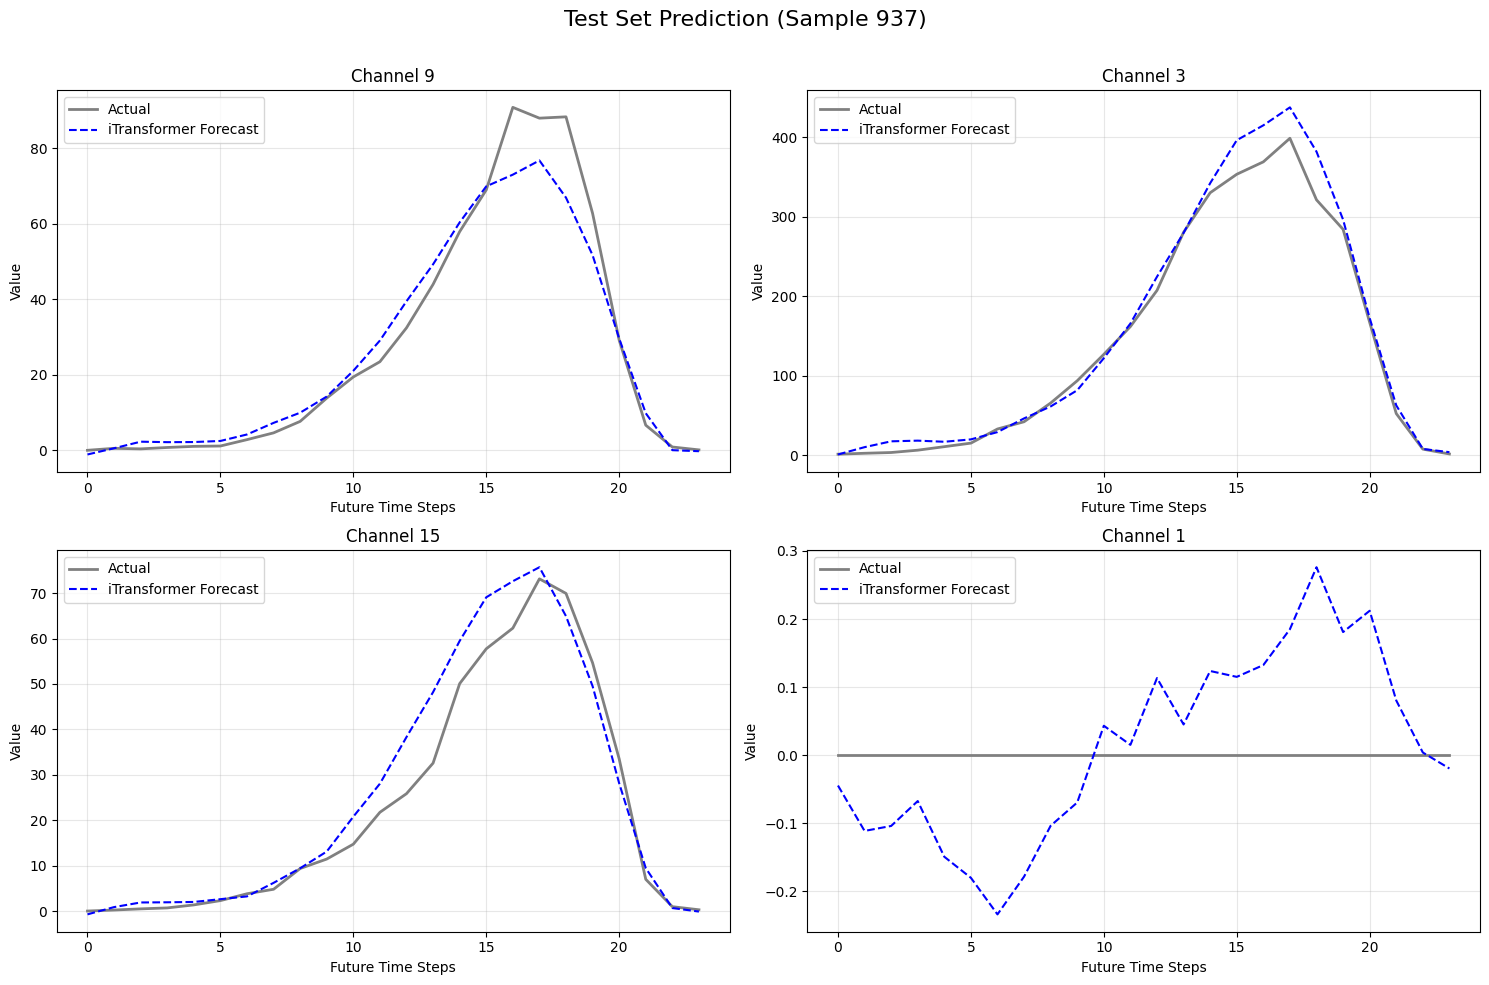

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def test_model(model, test_loader, scaler, device, mask=None, plot_samples=True):
    """
    Evaluates the model on the Test Set, calculates final metrics, 
    and plots Actual vs. Predicted values.
    """
    model.eval()
    
    all_preds = []
    all_targets = []
    
    print("Running Inference on Test Set...")
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # Forward pass
            preds = model(batch_x, mask=mask)
            
            # Collect results (move to CPU and convert to numpy)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(batch_y.cpu().numpy())

    # Concatenate all batches
    all_preds = np.concatenate(all_preds, axis=0)     # Shape: [Total_Samples, Pred_Len, Variates]
    all_targets = np.concatenate(all_targets, axis=0) # Shape: [Total_Samples, Pred_Len, Variates]
    
    # --- Inverse Scaling (Back to Real World Units) ---
    b, p, v = all_preds.shape
    
    # Reshape to 2D for the scaler, then reshape back to 3D
    preds_real = scaler.inverse_transform(all_preds.reshape(-1, v)).reshape(b, p, v)
    targets_real = scaler.inverse_transform(all_targets.reshape(-1, v)).reshape(b, p, v)

    # --- Metric Calculation ---
    # We calculate metrics across all samples and all channels
    mae = mean_absolute_error(targets_real.flatten(), preds_real.flatten())
    mse = mean_squared_error(targets_real.flatten(), preds_real.flatten())
    rmse = np.sqrt(mse)
    
    print("-" * 30)
    print("📊 FINAL TEST METRICS (Real Units)")
    print("-" * 30)
    print(f"MAE  (Mean Absolute Error): {mae:.4f}")
    print(f"MSE  (Mean Squared Error) : {mse:.4f}")
    print(f"RMSE (Root Mean Squared)  : {rmse:.4f}")
    print("-" * 30)

    # --- Visualization ---
    if plot_samples:
        # Pick a random sample from the test set to plot
        sample_idx = np.random.randint(0, b)
        
        # Define time steps for the X-axis
        time_steps = np.arange(p)
        
        plt.figure(figsize=(15, 10))
        plt.suptitle(f"Test Set Prediction (Sample {sample_idx})", fontsize=16)

        # Plot 4 random channels to see multivariate performance
        channels_to_plot = np.random.choice(range(v), size=4, replace=False)
        
        for i, ch in enumerate(channels_to_plot):
            plt.subplot(2, 2, i+1)
            plt.plot(time_steps, targets_real[sample_idx, :, ch], label='Actual', color='gray', linewidth=2)
            plt.plot(time_steps, preds_real[sample_idx, :, ch], label='iTransformer Forecast', color='blue', linestyle='--')
            plt.title(f"Channel {ch}")
            plt.xlabel("Future Time Steps")
            plt.ylabel("Value")
            plt.legend()
            plt.grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()

    return preds_real, targets_real, {"MAE": mae, "MSE": mse, "RMSE": rmse}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL = iTransformer(
        num_variates=CHANNELS,
        lookback_len=SEQ_LEN,
        pred_len=PRED_LEN,
        d_model=D_MODEL,   
        num_layers=NUM_LAYERS,  
        n_heads=4
    ).to(device)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

attn_mask = ATT_MASK.float().to(device) if MODEL_WITH_MASK else None

train_size = int(len(TSS) * 0.6)
test_size = len(TSS) - train_size
TEST_TSS = TSS.iloc[train_size:]

print(f"Test size: {test_size}")

TEST_TSS_SCALED = SCALER.fit_transform(TEST_TSS.values)
TEST_TSS_SCALED_DS = TimeSeriesDataset(TEST_TSS_SCALED, SEQ_LEN, PRED_LEN)
TEST_TSS_SCALED_DL = DataLoader(TEST_TSS_SCALED_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test DataLoader created, shape of batch: {next(iter(TEST_TSS_SCALED_DL))[0].shape}")

test_model(MODEL, TEST_TSS_SCALED_DL, SCALER, device, mask=None, plot_samples=True)
print()

Retrieving model from timeseries_itranformer_model.pth
torch.Size([1, 48, 16])
torch.Size([24, 16])
(48, 16)
(24, 16)
(24, 16)


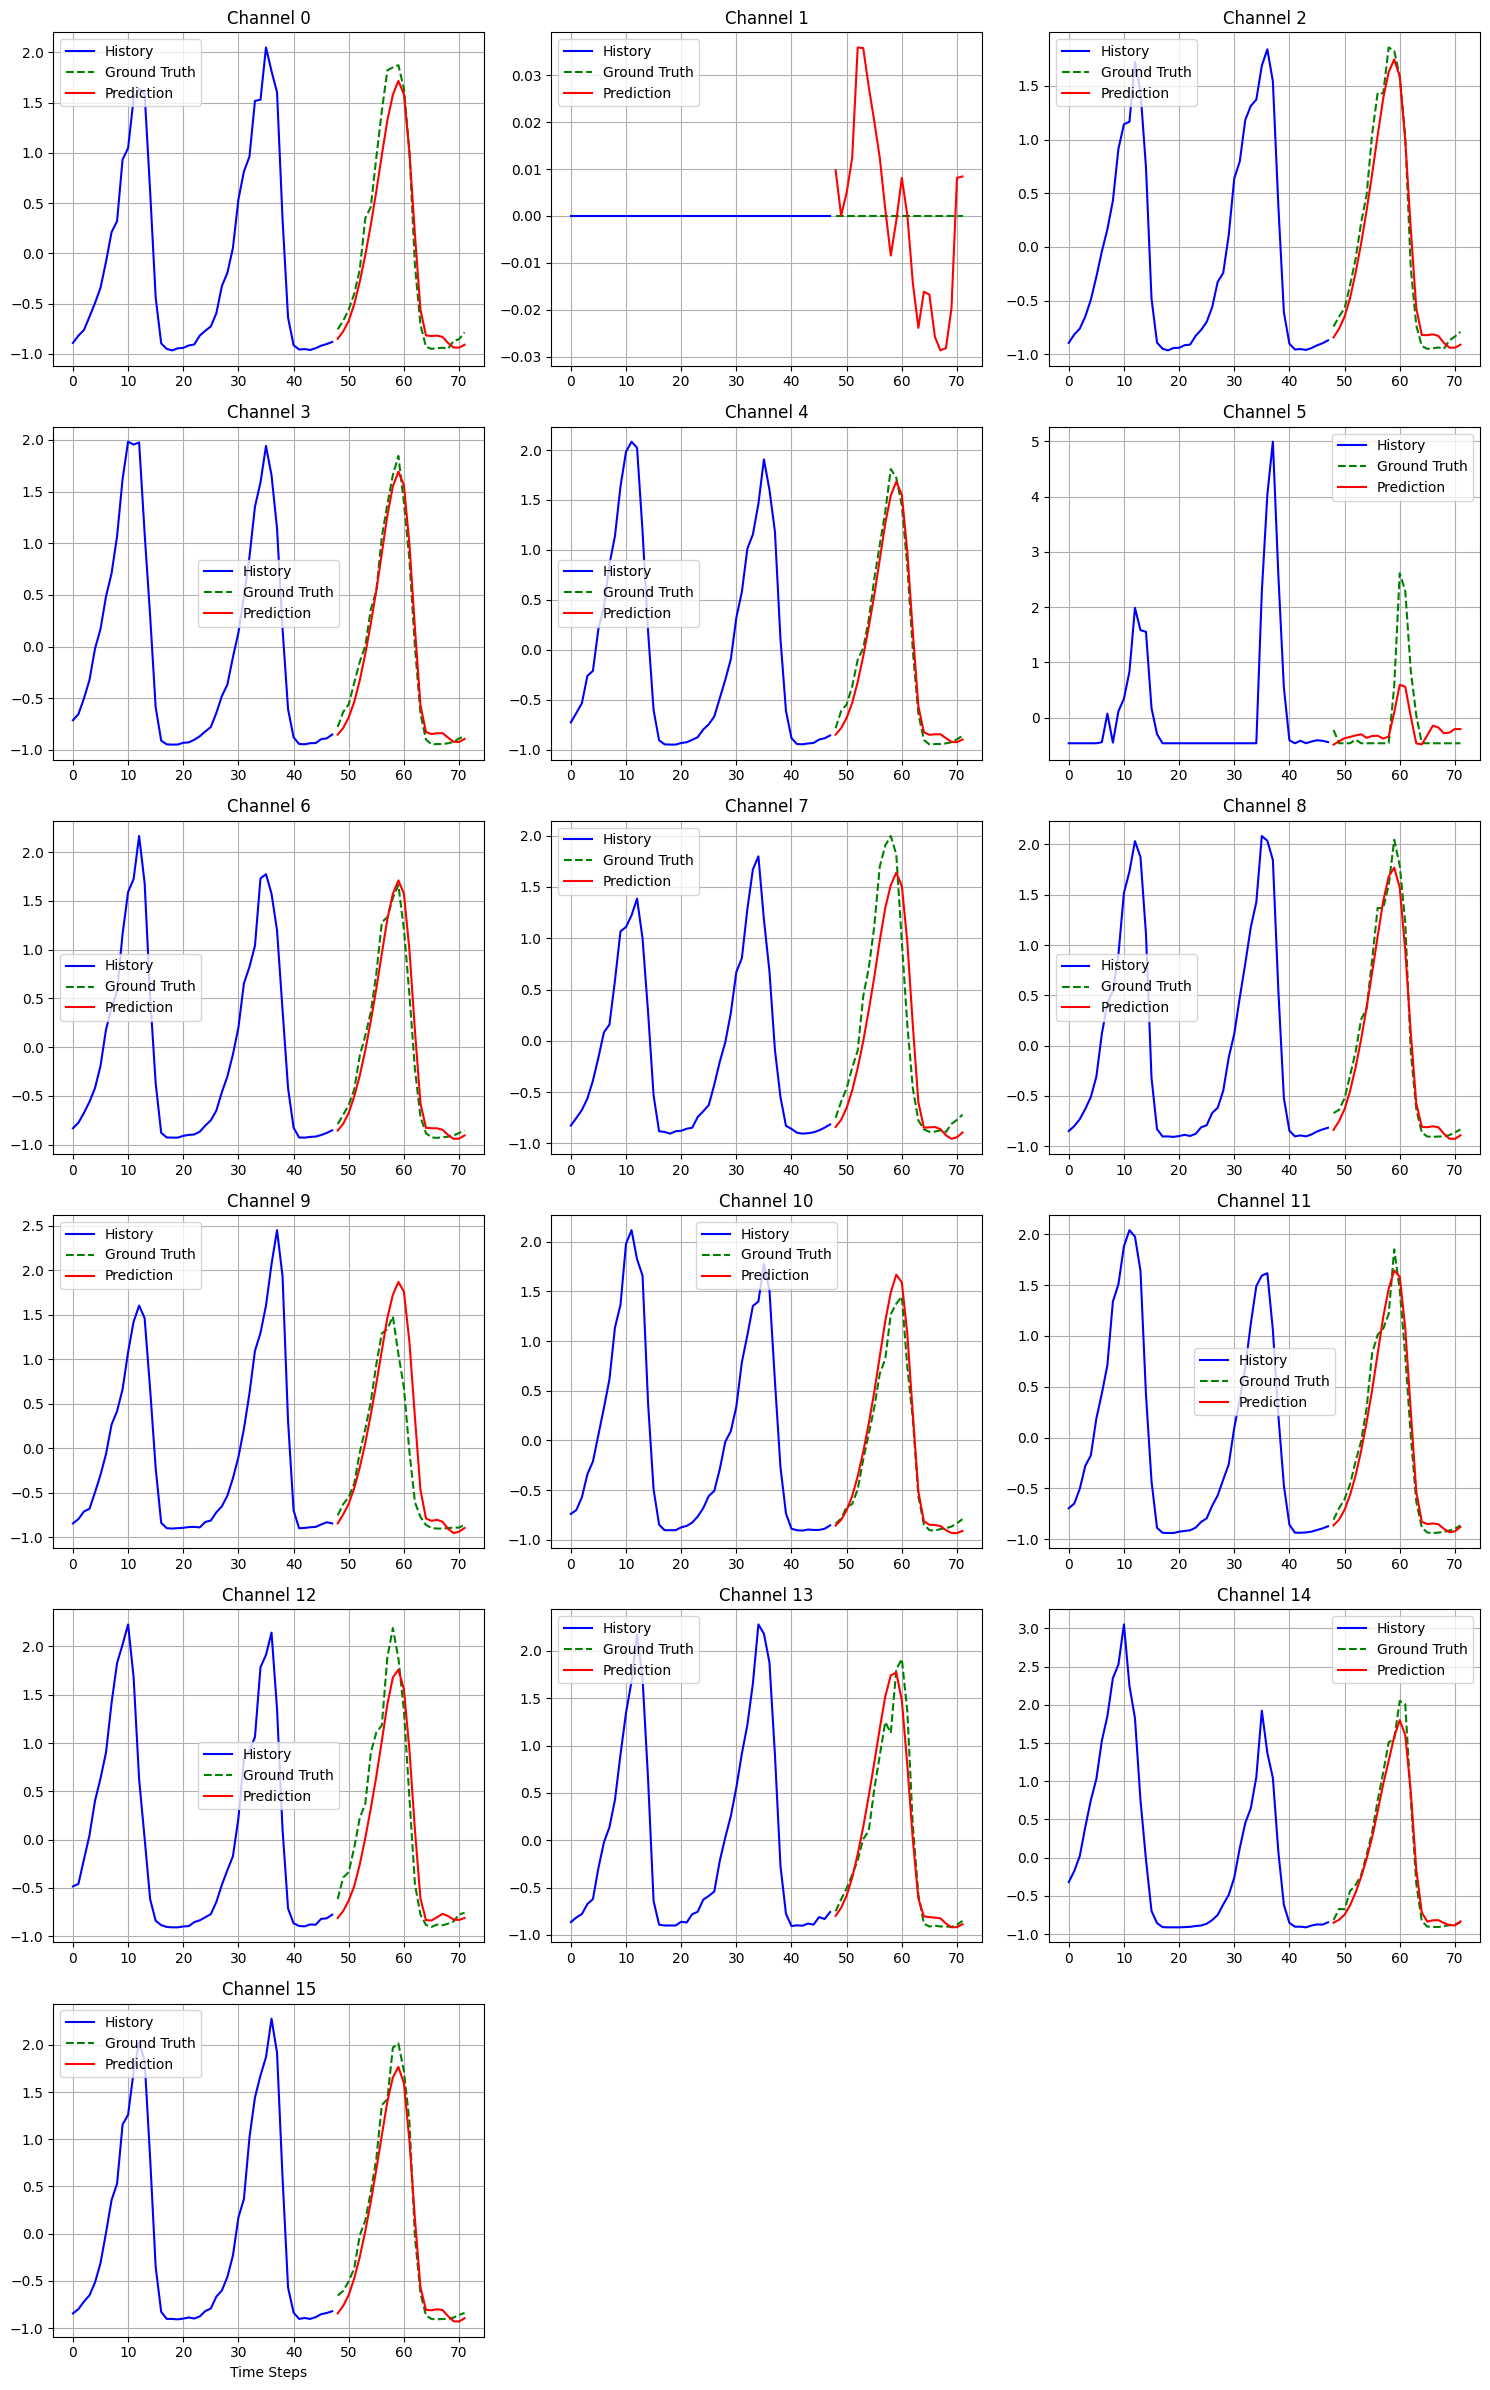

In [17]:
def plot_results(model, dataframe, seq_len, pred_len, mask=None, sample_idx=0):
    """
    Plots the Input History, Ground Truth Future, and Model Prediction for a specific sample.
    """
    dataset = TimeSeriesDataset(dataframe, seq_len, pred_len)
    input_x, true_y = dataset[sample_idx]


    # Add batch dimension for the model
    input_x_batch = input_x.unsqueeze(0)        # [1, seq_len, channels]

    print(input_x_batch.shape)
    print(true_y.shape)


    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        input_x_batch = input_x_batch.to(device)
        pred_y = model(input_x_batch, mask=mask)

    # Convert to numpy for plotting
    input_x = input_x.numpy()
    true_y = true_y.numpy()
    pred_y = pred_y.cpu().numpy().squeeze(0) # Remove batch dim
    print(input_x.shape)
    print(true_y.shape)
    print(pred_y.shape)



    # Plotting
    # --- Setup for Grid Layout ---
    num_cols = 3
    num_channels = input_x.shape[1]
    # Calculate rows needed (ceiling division)
    num_rows = (num_channels + num_cols - 1) // num_cols

    # Create the subplots
    # Note: Increased width (15) to accommodate 3 columns
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows), sharex=False)

    # Flatten the axes array (makes it 1D so we can iterate over it easily)
    # If num_channels is small, axes might not be an array, so we ensure it is iterable
    if num_channels == 1:
        axes = np.array([axes])
    axes_flat = axes.flatten()

    # Time axis for plotting
    x_history = np.arange(seq_len)
    x_future = np.arange(seq_len, seq_len + pred_len)


    for i in range(num_channels):
        ax = axes_flat[i]

        # Plot History
        ax.plot(x_history, input_x[:, i], label='History', color='blue')

        # Plot Ground Truth
        ax.plot(x_future, true_y[:, i], label='Ground Truth', color='green', linestyle='dashed')

        # Plot Prediction
        ax.plot(x_future, pred_y[:, i], label='Prediction', color='red')

        ax.set_title(f"Channel {i}")
        ax.legend()
        ax.grid(True)
    # --- Clean up empty subplots ---
    # If num_channels isn't a perfect multiple of 3, hide the empty axes at the end
    for i in range(num_channels, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    plt.xlabel("Time Steps")
    plt.tight_layout()
    #plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL = iTransformer(
        num_variates=CHANNELS,
        lookback_len=SEQ_LEN,
        pred_len=PRED_LEN,
        d_model=D_MODEL,   
        num_layers=NUM_LAYERS,  
        n_heads=4
    ).to(device)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

attn_mask = ATT_MASK.float().to(device) if MODEL_WITH_MASK else None


plot_results(MODEL, TSS_SCALED, SEQ_LEN, PRED_LEN, mask=None, sample_idx=55)

In [41]:
## PREDICTION
def predict_future_dataframe(model, dataframe, seq_len, pred_len, freq='h', scaler=None, mask=None, device='cpu'):

    model.to(device)
    model.eval()

    data_scaled= scaler.transform(dataframe.values)
    dataset = TimeSeriesDataset(data_scaled, seq_len, pred_len)
    
    last_idx = len(dataset) - 1
    input_x, true_y = dataset[last_idx]

    input_x = input_x.unsqueeze(0).to(device)         # [B, L, C]
    true_y = true_y.unsqueeze(0).to(device) # [B, L, 4]


    with torch.no_grad():
        preds = model(input_x, mask=mask)

    preds = preds.cpu().numpy().squeeze()
    preds = scaler.inverse_transform(preds)

    last_date = dataframe.index[-1]
  

    future_dates = pd.date_range(start=last_date, periods=pred_len, freq=freq)
    

    
    return  pd.DataFrame(preds, index=future_dates, columns=dataframe.columns)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'

MODEL = iTransformer(
        num_variates=CHANNELS,
        lookback_len=SEQ_LEN,
        pred_len=PRED_LEN,
        d_model=D_MODEL,   
        num_layers=NUM_LAYERS,  
        n_heads=4
    ).to(device)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

attn_mask = ATT_MASK.float().to(device) if MODEL_WITH_MASK else None


TSS_PRED = TSS.copy()
OFFSET_PRED = TSS_PRED.index[-1]

PREDICTION_RANGE = 50
for _ in range(PREDICTION_RANGE):

    TSS_PRED = pd.concat([TSS_PRED, predict_future_dataframe(MODEL, TSS_PRED, SEQ_LEN, PRED_LEN, freq=f'{FREQ_H}h', scaler=SCALER, mask=attn_mask, device=device)], axis=0)


Retrieving model from timeseries_itranformer_model.pth


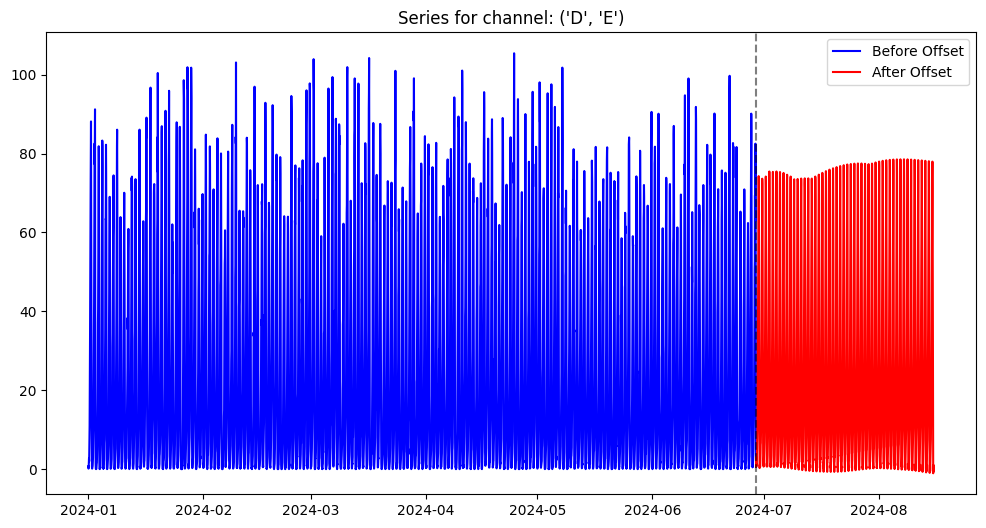

In [43]:
def plot_prediction(data:pd.Series, offset):

    plt.figure(figsize=(12, 6))
    plt.plot(data.loc[:offset], color='blue', label='Before Offset')
    plt.plot(data.loc[offset:], color='red', label='After Offset')
    plt.axvline(offset, color='black', linestyle='--', alpha=0.5)
    plt.title(f"Series for channel: {data.columns[0]}")
    plt.legend()
    plt.show()

_rand_chan = TSS_PRED.T.sample(1).index[0]
_tss_plot = TSS_PRED[[_rand_chan]]

plot_prediction(_tss_plot, OFFSET_PRED)



In [17]:
timestamp = TSS_PRED[TSS_PRED.index > OFFSET_PRED].T.sum().idxmax() 
print(timestamp)

visualize_flow_series(TSS_PRED.loc[timestamp,:])

2024-08-01 14:00:00


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 400000, 'idealEdgeLength': 100, 'gravity': …

# WHAT IF



the link is ('E', 'S4') in channel 15 and the multiplier is 0.5


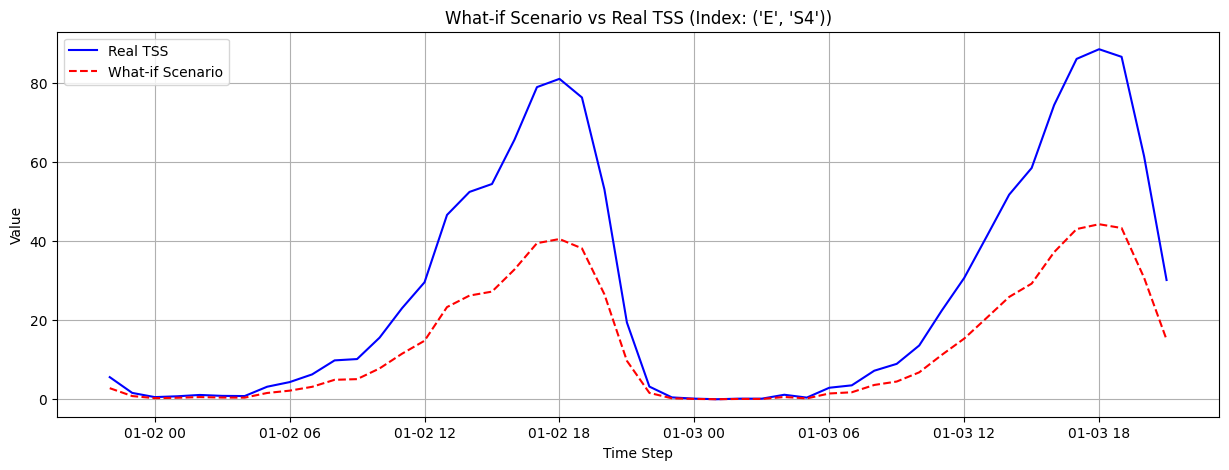

In [36]:
IDX = 22
TSS_REAL = TSS.copy()
TSS_REAL = TSS_REAL.iloc[IDX:IDX+SEQ_LEN]

TSS_WHATIF = TSS_REAL.copy()
OFFSET_PRED = TSS_WHATIF.index[-1]

COLS_CONV = {col:i for i,col in enumerate(TSS.columns)}

what_if_idx = ('E', 'S4')
what_if_idx_num = COLS_CONV[what_if_idx]

multiplier = .5
print(f"the link is {what_if_idx} in channel {what_if_idx_num} and the multiplier is {multiplier}")

TSS_WHATIF[what_if_idx] *= multiplier


plt.figure(figsize=(15, 5))
plt.plot(TSS_REAL[what_if_idx], label='Real TSS', color='blue')
plt.plot(TSS_WHATIF[what_if_idx], label='What-if Scenario', color='red', linestyle='--')
plt.title(f'What-if Scenario vs Real TSS (Index: {what_if_idx})')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
device = 'cuda'
MODEL = iTransformer(
        num_variates=CHANNELS,
        lookback_len=SEQ_LEN,
        pred_len=PRED_LEN,
        d_model=D_MODEL,   
        num_layers=NUM_LAYERS,  
        n_heads=NUM_HEADS,
    ).to(device)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)
FORGET_PAST = True

demand_links_num = [COLS_CONV[x] for x in DEMAND_LINKS]

attn_mask = ATT_MASK.float().to(device) if MODEL_WITH_MASK else None
attn_mask = None
print(f"the attention mask is {MODEL_WITH_MASK}")
attn_mask


Retrieving model from timeseries_itranformer_model.pth
the attention mask is True


In [45]:
TSS_WHATIF

HR_A MR_B MR_A HR_B MR_B    C    B           C    D  \
                    MR_A MR_A    C MR_B    A    D    D          S7    E   
2024-01-01 22:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    2.503434  0.0   
2024-01-01 23:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.387458  0.0   
2024-01-02 00:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.129638  0.0   
2024-01-02 01:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.000000  0.0   
2024-01-02 02:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.000000  0.0   
2024-01-02 03:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.255886  0.0   
2024-01-02 04:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.247993  0.0   
2024-01-02 05:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.367966  0.0   
2024-01-02 06:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.810305  0.0   
2024-01-02 07:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    1.668606  0.0   
2024-01-02 08:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    4.049234  0.0   
2024-01-02 09:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    7.569044  0.0   
2024-01-02 10:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   12.164626  0.0   
2024-01-02 11:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   15.737142  0.0   
2024-01-02 12:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   25.655969  0.0   
2024-01-02 13:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   36.331946  0.0   
2024-01-02 14:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   45.112997  0.0   
2024-01-02 15:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   61.621537  0.0   
2024-01-02 16:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   66.734563  0.0   
2024-01-02 17:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   93.757107  0.0   
2024-01-02 18:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  105.555936  0.0   
2024-01-02 19:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   90.316974  0.0   
2024-01-02 20:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   69.438766  0.0   
2024-01-02 21:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   34.969294  0.0   
2024-01-02 22:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    6.797629  0.0   
2024-01-02 23:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    2.111088  0.0   
2024-01-03 00:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.110644  0.0   
2024-01-03 01:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.000000  0.0   
2024-01-03 02:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.245442  0.0   
2024-01-03 03:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.124976  0.0   
2024-01-03 04:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    0.129548  0.0   
2024-01-03 05:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    1.294589  0.0   
2024-01-03 06:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    1.676330  0.0   
2024-01-03 07:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    2.869821  0.0   
2024-01-03 08:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    6.681976  0.0   
2024-01-03 09:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    9.784048  0.0   
2024-01-03 10:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   13.166817  0.0   
2024-01-03 11:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   23.703807  0.0   
2024-01-03 12:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   29.958206  0.0   
2024-01-03 13:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   40.862070  0.0   
2024-01-03 14:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   56.087541  0.0   
2024-01-03 15:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   77.299993  0.0   
2024-01-03 16:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   80.730662  0.0   
2024-01-03 17:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   81.717614  0.0   
2024-01-03 18:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   75.005507  0.0   
2024-01-03 19:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   63.425428  0.0   
2024-01-03 20:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   33.011877  0.0   
2024-01-03 21:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0    9.254216  0.0   

                                             A                        \
                            S6         S5    B         S1         S2   
2024-01-01 22:00:00  16.180567  14.158098  0.0   6.826449  17.751587   
2024-01-01 23:00:00   1.632240   2.227626  0.0   1.54

In [46]:
MODEL.eval()

if FORGET_PAST:
    print("FORGET_PAST")
    NON_DEMAND_LINKS = [x for x in TSS_WHATIF.columns if x[1] not in DEMANDS_NODES]
    TSS_WHATIF.loc[:,NON_DEMAND_LINKS] = 0


what_if_input = SCALER.transform(TSS_WHATIF.values)
what_if_input = torch.tensor(what_if_input).float().unsqueeze(0).to(device)
what_if_input_back = what_if_input.clone()

what_if_input_scenario = what_if_input[:,:,what_if_idx_num].reshape(1, SEQ_LEN, 1)

print(f"What if input shape: {what_if_input.shape}")
print(f"What if input scenario shape: {what_if_input_scenario.shape}")

what_if_pred = []
with torch.no_grad():
    for i in range(SEQ_LEN):
       

        real_pred = MODEL(what_if_input, mask=attn_mask)
        next_step_pred = real_pred[:,0:1,:]
        next_step_pred_what_if = next_step_pred.clone()

        for demand_id in demand_links_num:
            #next_step_pred_what_if[:,:,what_if_idx_num] = what_if_input_back[:,i%what_if_input_back.shape[1],what_if_idx_num] 
            next_step_pred_what_if[:,:,demand_id] = what_if_input_back[:,i%what_if_input_back.shape[1],demand_id] 


        what_if_pred.append(next_step_pred_what_if)

        what_if_input = torch.cat([what_if_input[:,1:,:], next_step_pred_what_if], dim=1)


WHAT_IF_PRED = torch.cat(what_if_pred, dim=1)
WHAT_IF_PRED = WHAT_IF_PRED.cpu().numpy().squeeze(0)
WHAT_IF_PRED = SCALER.inverse_transform(WHAT_IF_PRED)
#WHAT_IF_PRED = pd.DataFrame(WHAT_IF_PRED, columns=TSS_WHATIF.columns, index=TSS_WHATIF.index[:len(WHAT_IF_PRED)])
WHAT_IF_PRED = pd.DataFrame(WHAT_IF_PRED, columns=TSS_WHATIF.columns)

WHAT_IF_PRED

FORGET_PAST
What if input shape: torch.Size([1, 48, 16])
What if input scenario shape: torch.Size([1, 48, 1])


HR_A      MR_B       MR_A        HR_B        MR_B         C  \
         MR_A      MR_A          C        MR_B           A         D   
0   -3.814655 -0.624540  -3.823271  -18.865082  -18.820877 -0.050466   
1   -6.364046 -0.913751  -6.369785  -24.598694  -24.542770 -0.095898   
2   -1.123547 -1.172078  -1.115955    1.973938    1.966980 -0.136440   
3   -0.551729 -1.045859  -0.540535    6.483582    6.465652 -0.113484   
4   -0.113739 -0.914989  -0.102293    8.319778    8.297546 -0.101469   
5    1.845547 -0.826010   1.862200   19.010422   18.962677 -0.072642   
6    9.363272 -0.790235   9.400944   32.504837   32.438690 -0.068413   
7   14.487307 -0.777356  14.534444   70.076149   69.912415 -0.080990   
8   28.746157 -0.587855  28.840818  147.472244  147.125992 -0.045536   
9   31.301897 -0.488314  31.404156  163.113953  162.728455 -0.054365   
10  32.902618 -0.475439  33.003937  157.998062  157.631409 -0.062316   
11  28.320604 -0.501719  28.403736  127.107368  126.815491 -0.076716   
12  22.204313 -0.349289  22.260502   88.096878   87.895844 -0.062060   
13  11.069214 -0.534390  11.105375   45.099358   45.000450 -0.089249   
14  12.595429 -0.800726  12.636834   63.208778   63.060539 -0.094904   
15  12.727091 -0.928788  12.771722   56.030464   55.897667 -0.100725   
16  23.749704 -0.768018  23.827465  115.130905  114.854797 -0.070896   
17  41.985458  0.178680  42.131050  244.465332  243.876602  0.049211   
18  50.322533  0.633077  50.489021  288.194031  287.502960  0.119424   
19  57.008121  1.047456  57.187805  305.850586  305.118896  0.154422   
20  59.041477  1.882940  59.222206  316.360291  315.603668  0.249692   
21  71.283119  2.242502  71.480423  362.109253  361.248474  0.303381   
22  57.822792  2.243200  57.993591  274.606506  273.976257  0.305928   
23  26.735035  1.875532  26.801607  112.252274  111.997574  0.252595   
24   1.891895  1.293238   1.903650   12.760773   12.730759  0.175871   
25  -0.456221 -0.079046  -0.448179    3.969513    3.958237  0.007335   
26  -1.010771 -0.815061  -1.001167    3.589569    3.579254 -0.092150   
27  -1.782173 -0.904298  -1.775581   -0.686615   -0.687256 -0.105004   
28  -1.734453 -0.897075  -1.728561   -2.179489   -2.176071 -0.102792   
29  -0.126072 -0.864211  -0.114311    8.461655    8.439224 -0.097851   
30   0.241951 -0.860920   0.254047   10.265182   10.237808 -0.097414   
31   2.200001 -0.836806   2.226965   26.065231   25.998894 -0.095893   
32   3.732140 -0.922270   3.758190   28.993858   28.922523 -0.104506   
33   0.846432 -0.880535   0.865559   38.834770   38.733185 -0.097369   
34   6.128422 -0.788384   6.157217   49.879517   49.755440 -0.083911   
35  10.064692 -0.817265  10.113809   72.820534   72.645081 -0.085946   
36  14.419640 -0.736983  14.477689   78.603088   78.414696 -0.076154   
37  20.931927 -0.627203  21.012402  109.901825  109.638229 -0.057956   
38  28.237482 -0.471896  28.328150  150.701019  150.348038 -0.031809   
39  35.151958 -0.150626  35.263924  190.703247  190.257782  0.006052   
40  47.064236  0.151411  47.206238  252.826172  252.226700  0.038455   
41  59.069633  0.524503  59.244633  322.670715  321.909302  0.087593   
42  73.011185  0.824285  73.224449  361.662506  360.822662  0.126989   
43  83.958618  1.279647  84.210922  426.861938  425.850586  0.179973   
44  85.865234  1.825485  86.136200  472.438965  471.314667  0.255152   
45  78.912857  1.856134  79.168350  454.839783  453.751465  0.255124   
46  65.359589  1.618787  65.583710  411.944336  410.956207  0.225192   
47  30.318563  0.882059  30.434282  225.875977  225.297516  0.121320   

             B           C          D                                 A  \
             D          S7          E         S6         S5           B   
0    -9.970970    2.503435  -3.822969  16.180567  14.158098  -12.617203   
1   -14.015213    0.387459  -6.375896   1.632240   2.227625  -16.570923   
2    -0.217735    0.129641  -1.123613   0.099533   0.284481    1.161987   
3     1.935158    0.000002  -0.55

<Axes: >

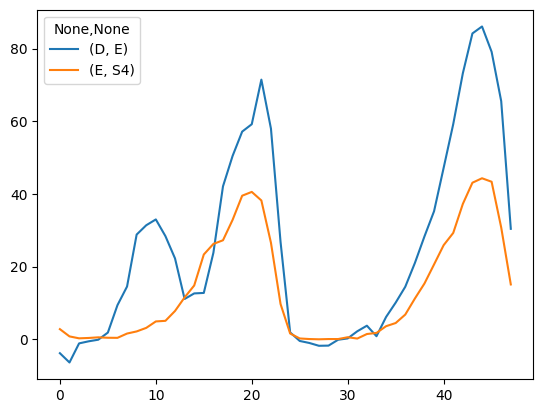

In [47]:
WHAT_IF_PRED[[('D','E'),('E','S4')]].iloc[:].plot()

<Axes: >

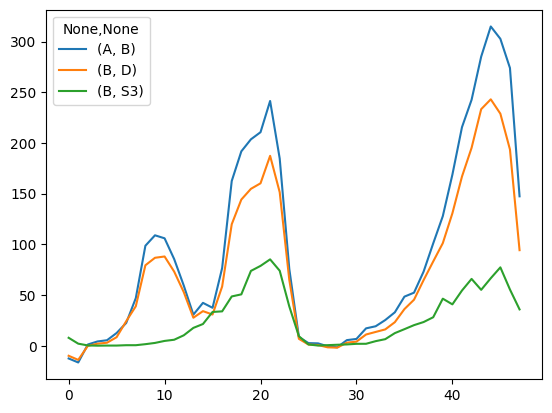

In [48]:
WHAT_IF_PRED[[('A','B'),('B','D'),('B','S3')]].plot()

In [218]:
timestamp = WHAT_IF_PRED.T.sum().idxmax() 
print(timestamp)

visualize_flow_series(WHAT_IF_PRED.loc[timestamp,:])

98


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 400000, 'idealEdgeLength': 100, 'gravity': …

In [197]:
MODEL.eval()

x_input = SCALER.transform(TSS_REAL.values)
x_input = torch.tensor(x_input).float().unsqueeze(0).to(device)

what_if_input = SCALER.transform(TSS_WHATIF.values)
what_if_input = torch.tensor(what_if_input).float().unsqueeze(0).to(device)
what_if_input_scenario = what_if_input[:,:,what_if_idx_num].reshape(1, SEQ_LEN, 1)

print(f"Real input shape: {x_input.shape}")
print(f"What if input shape: {what_if_input.shape}")
print(f"What if input scenario shape: {what_if_input_scenario.shape}")

what_if_pred = []
with torch.no_grad():
    for i in range(SEQ_LEN+1000):
        print(i)

        real_pred = MODEL(x_input, mask=attn_mask)
        next_step_pred = real_pred[:,0:1,:]
        next_step_pred_what_if = next_step_pred.clone()

        if i < SEQ_LEN:
            next_step_pred_what_if[:,:,what_if_idx_num] = what_if_input_scenario[:,i,:]


        what_if_pred.append(next_step_pred_what_if)

        x_input = torch.cat([x_input[:,1:,:], next_step_pred_what_if], dim=1)

        clear_output(wait=True)

WHAT_IF_PRED = torch.cat(what_if_pred, dim=1)
WHAT_IF_PRED = WHAT_IF_PRED.cpu().numpy().squeeze(0)
WHAT_IF_PRED = SCALER.inverse_transform(WHAT_IF_PRED)
#WHAT_IF_PRED = pd.DataFrame(WHAT_IF_PRED, columns=TSS_WHATIF.columns, index=TSS_WHATIF.index[:len(WHAT_IF_PRED)])
WHAT_IF_PRED = pd.DataFrame(WHAT_IF_PRED, columns=TSS_WHATIF.columns)

WHAT_IF_PRED


HR_A      MR_B        MR_A        HR_B        MR_B           C  \
            MR_A      MR_A           C        MR_B           A           D   
0      38.712608  0.004486   45.234432   18.502155   23.827358   37.782288   
1      14.212105  0.004935   14.179947    1.773727    4.454613   12.160263   
2       1.674240  0.001765    2.028442   -0.436462    0.370247    3.720596   
3       1.671875  0.003253   -0.089851   -0.402214    1.060730   -0.622162   
4       3.425270  0.002106    1.872993    1.458534    2.030716    1.389984   
...          ...       ...         ...         ...         ...         ...   
1715   41.891567  0.002019   43.323765   36.480728   35.911934   36.600742   
1716   63.925453  0.003393   65.518860   54.850319   53.299145   53.325211   
1717   91.532104  0.003362   92.837334   75.944710   73.908058   75.656715   
1718  119.776031  0.002927  121.827377   98.837029   96.752480  101.777061   
1719  154.505325  0.002634  157.741913  127.116936  123.821976  133.839874   

             B          C          D                                A  \
             D         S7          E         S6         S5          B   
0     0.005749   3.714336   3.980877  10.685850  10.022163  15.482780   
1    -0.015357   0.640205   0.458862   1.765049   4.825890   4.557383   
2    -0.004755  -0.121452  -0.028406  -0.914696   2.009367   1.310043   
3     0.007889   0.981401   0.312647  -0.560375   0.495779   0.424864   
4    -0.006470   0.976755   0.218691   0.853235   0.629570   0.587666   
...        ...        ...        ...        ...        ...        ...   
1715 -0.103189  10.182841  17.499220  11.130670  12.817986  10.225297   
1716 -0.127450  16.283689  25.129593  17.553791  18.585777  16.079275   
1717 -0.128063  23.473698  35.045540  25.529650  27.430241  24.029598   
1718 -0.121271  30.972286  46.845192  33.959869  36.310349  32.609978   
1719 -0.111792  40.600487  61.603142  44.216087  45.000320  42.704189   

                                    B          E  
             S1         S2         S3         S4  
0      2.885002   5.005684  15.944801   0.071461  
1      1.051771   2.097946   4.627789   0.024788  
2      1.683456   1.261164   1.485138   0.029745  
3      1.459763   1.281723   0.588915   0.078596  
4      1.448696   1.132666   0.734837   0.074764  
...         ...        ...        ...        ...  
1715   9.548998   9.628816  10.268924  49.549831  
1716  14.215275  14.782883  16.326389  54.768211  
1717  19.077858  22.185112  24.258680  58.337074  
1718  24.724585  30.385208  32.643791  60.236320  
1719  32.609821  39.444778  42.858398  48.131363  

[1720 rows x 16 columns]

<Axes: >

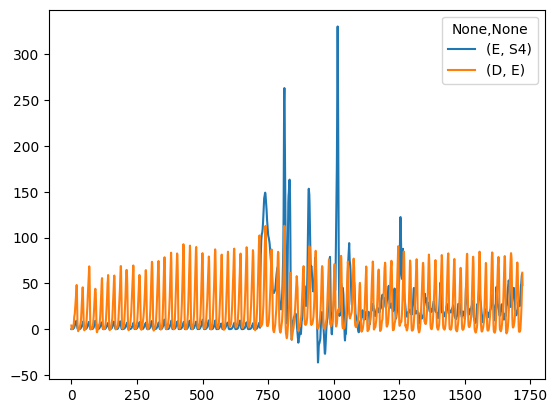

In [199]:
WHAT_IF_PRED[[('E','S4'),('D','E')]].plot()

In [103]:
timestamp = TSS_WHATIF.sum(axis=1).idxmax()
print(timestamp)

visualize_flow_series(TSS_WHATIF.loc[timestamp,:])

2024-01-07 18:00:00


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 400000, 'idealEdgeLength': 100, 'gravity': …

#### FORGET THE PAST

In [285]:
NON_DEMAND_LINKS = [x for x in TSS_REAL.columns if x[1] not in DEMANDS_NODES]
TSS_REAL.loc[:,NON_DEMAND_LINKS] = 0

In [286]:
TSS_REAL

HR_A MR_B MR_A HR_B MR_B    C    B          C    D  \
                    MR_A MR_A    C MR_B    A    D    D         S7    E   
2024-01-01 22:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   1.548945  0.0   
2024-01-01 23:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.463004  0.0   
2024-01-02 00:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.154949  0.0   
2024-01-02 01:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.000000  0.0   
2024-01-02 02:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.440690  0.0   
...                  ...  ...  ...  ...  ...  ...  ...        ...  ...   
2024-01-31 17:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  58.653982  0.0   
2024-01-31 18:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  62.105051  0.0   
2024-01-31 19:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  68.124810  0.0   
2024-01-31 20:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  50.198171  0.0   
2024-01-31 21:00:00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  25.055668  0.0   

                                             A                        \
                            S6         S5    B         S1         S2   
2024-01-01 22:00:00   0.685578   1.675094  0.0  25.967586   8.230358   
2024-01-01 23:00:00   0.279444   0.145077  0.0   6.124139   1.972477   
2024-01-02 00:00:00   0.242130   0.218191  0.0   0.647873   0.220231   
2024-01-02 01:00:00   0.261723   0.000000  0.0   0.782799   0.469192   
2024-01-02 02:00:00   0.564524   0.330593  0.0   1.215265   0.216421   
...                        ...        ...  ...        ...        ...   
2024-01-31 17:00:00  93.907755  67.663942  0.0  72.379186  76.689288   
2024-01-31 18:00:00  83.792507  79.918643  0.0  71.201857  45.396512   
2024-01-31 19:00:00  99.463184  76.187016  0.0  56.498662  21.311590   
2024-01-31 20:00:00  57.152622  61.464153  0.0  34.072184   9.468949   
2024-01-31 21:00:00  16.458796  40.721963  0.0  10.570450   2.547480   

                             B          E  
                            S3         S4  
2024-01-01 22:00:00   2.057545  22.295519  
2024-01-01 23:00:00   0.138461   4.360613  
2024-01-02 00:00:00   0.249961   0.249684  
2024-01-02 01:00:00   0.138427   0.130806  
2024-01-02 02:00:00   0.495865   0.238286  
...                        ...        ...  
2024-01-31 17:00:00  52.707659  51.433643  
2024-01-31 18:00:00  59.415075  34.354057  
2024-01-31 19:00:00  63.607630  20.673374  
2024-01-31 20:00:00  60.723353   7.381968  
2024-01-31 21:00:00  41.746729   2.680076  

[720 rows x 16 columns]

In [287]:
MODEL.eval()

x_input = SCALER.transform(TSS_REAL.values)
x_input = torch.tensor(x_input).float().unsqueeze(0).to(device)

what_if_input = SCALER.transform(TSS_WHATIF.values)
what_if_input = torch.tensor(what_if_input).float().unsqueeze(0).to(device)
what_if_input_scenario = what_if_input[:,:,what_if_idx_num].reshape(1, SEQ_LEN, 1)

print(f"Real input shape: {x_input.shape}")
print(f"What if input shape: {what_if_input.shape}")
print(f"What if input scenario shape: {what_if_input_scenario.shape}")

what_if_pred = []
with torch.no_grad():
    for i in range(SEQ_LEN+1000):
        print(i)

        real_pred = MODEL(x_input, mask=attn_mask)
        next_step_pred = real_pred[:,0:1,:]
        next_step_pred_what_if = next_step_pred.clone()

        if i < SEQ_LEN:
            next_step_pred_what_if[:,:,what_if_idx_num] = what_if_input_scenario[:,i,:]


        what_if_pred.append(next_step_pred_what_if)

        x_input = torch.cat([x_input[:,1:,:], next_step_pred_what_if], dim=1)

        clear_output(wait=True)

WHAT_IF_PRED = torch.cat(what_if_pred, dim=1)
WHAT_IF_PRED = WHAT_IF_PRED.cpu().numpy().squeeze(0)
WHAT_IF_PRED = SCALER.inverse_transform(WHAT_IF_PRED)
#WHAT_IF_PRED = pd.DataFrame(WHAT_IF_PRED, columns=TSS_WHATIF.columns, index=TSS_WHATIF.index[:len(WHAT_IF_PRED)])
WHAT_IF_PRED = pd.DataFrame(WHAT_IF_PRED, columns=TSS_WHATIF.columns)

1719


In [292]:
WHAT_IF_PRED[[('E','S4'),('D','E')]].mean(axis=0)

E  S4    19.742405
D  E     23.515842
dtype: float32

<Axes: >

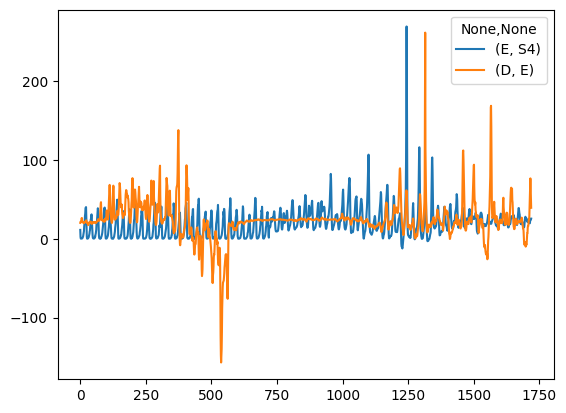

In [290]:
WHAT_IF_PRED[[('E','S4'),('D','E')]].plot()

<Axes: >

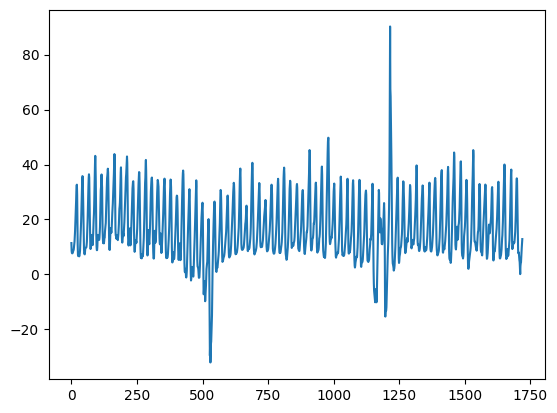

In [299]:
WHAT_IF_PRED[[('A','B'),('B','D'),('B','S3')]].mean(axis=1).plot()

HR_A MR_B MR_A HR_B MR_B    C    B    C    D              A       \
          MR_A MR_A    C MR_B    A    D    D   S7    E   S6   S5    B   S1   
HR_A MR_A  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0   
MR_B MR_A  0.0  0.0  0.6  0.0  0.0  0.0  0.0  0.1  0.0  0.0  0.0  0.0  0.1   
MR_A C     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0   
HR_B MR_B  0.0  0.1  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0   
MR_B A     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0   
C    D     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0   
B    D     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0   
C    S7    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.1   
D    E     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0   
     S6    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.1   
     S5    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.1  0.0  0.2  0.0  0.0  0.4   
A    B     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0   
     S1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.1  0.0  0.1  0.2  0.0  0.1   
     S2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.5  0.1  0.0  0.2   
B    S3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.1  0.0  0.4  0.1  0.0  0.2   
E    S4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.2  0.0  0.2  0.2  0.0  0.0   

                  B    E  
            S2   S3   S4  
HR_A MR_A  0.1  0.3  0.4  
MR_B MR_A  0.1  0.1  0.0  
MR_A C     0.1  0.3  0.4  
HR_B MR_B  0.1  0.1  0.4  
MR_B A     0.1  0.3  0.4  
C    D     0.1  0.3  0.4  
B    D     0.1  0.2  0.4  
C    S7    0.2  0.0  0.5  
D    E     0.1  0.3  0.4  
     S6    0.3  0.0  0.4  
     S5    0.2  0.0  0.2  
A    B     0.1  0.3  0.4  
     S1    0.4  0.0  0.1  
     S2    0.0  0.0  0.1  
B    S3    0.1  0.0  0.2  
E    S4    0.3  0.1  0.0

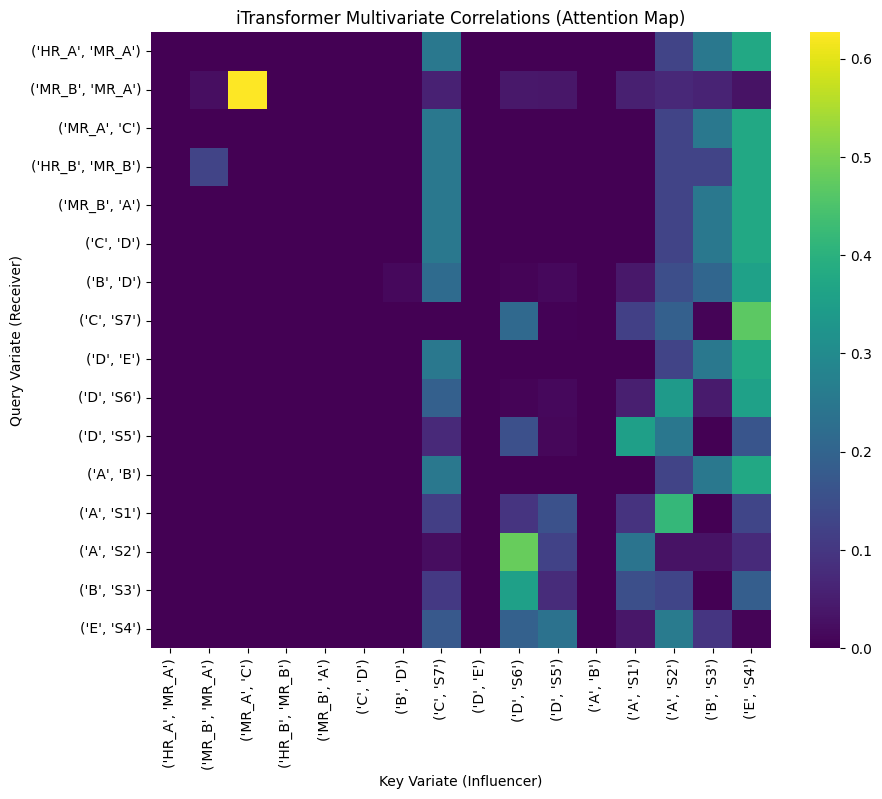

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def get_attention_matrix(model, scaler, raw_input, layer_idx=0, mask=None, device='cpu'):
    """
    Extracts the attention weights between variates from a specific encoder layer.
    
    Args:
        model: Trained iTransformer model.
        scaler: The scaler used during training.
        raw_input: Numpy array of shape (Lookback, Num_Variates).
        layer_idx: Which Transformer layer to inspect (0 is the first layer).
        
    Returns:
        attn_weights: Numpy array of shape (Num_Variates, Num_Variates).
    """
    model.eval()
    
    input_scaled = scaler.transform(raw_input)
    tensor_x = torch.tensor(input_scaled).float().unsqueeze(0).to(device) # Shape: (1, Lookback, N)

    if mask is not None:
        mask = mask.to(device)

    with torch.no_grad():

        x = tensor_x.permute(0, 2, 1)
        x_embedded = model.embedding(x)
        

        encoder_layer = model.encoder.layers[layer_idx]
        self_attn = encoder_layer.self_attn
        

        attn_output, attn_weights = self_attn(
            x_embedded, 
            x_embedded, 
            x_embedded, 
            attn_mask=mask,
            need_weights=True,
            average_attn_weights=True
        )
        
        return attn_weights[0].cpu().numpy()

def plot_attention_heatmap(attn_matrix, column_names=None):
    plt.figure(figsize=(10, 8))
    
    # Create labels if not provided
    if column_names is None:
        column_names = [f"Ch{i}" for i in range(attn_matrix.shape[0])]
        
    sns.heatmap(
        attn_matrix, 
        xticklabels=column_names, 
        yticklabels=column_names, 
        cmap="viridis", 
        annot=False # Set to True if you want to see the exact numbers
    )
    
    plt.title("iTransformer Multivariate Correlations (Attention Map)")
    plt.xlabel("Key Variate (Influencer)")
    plt.ylabel("Query Variate (Receiver)")
    plt.show()



attn_weights = get_attention_matrix(MODEL, SCALER, TSS_WHATIF, mask=attn_mask, layer_idx=2, device=device)

ATTENTION_DF = pd.DataFrame(attn_weights, index=TSS_WHATIF.columns, columns=TSS_WHATIF.columns)
display(ATTENTION_DF.round(1))

plot_attention_heatmap(attn_weights, column_names=TSS_WHATIF.columns)


